In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\UV TECH\Python\Practice\Csv Python File\ChurnEda.csv")

In [3]:
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churned/Retained,Unnamed: 12,Unnamed: 13
0,15634602,619,France,Female,42.0,2.0,0.00,1.0,1,1.0,101348.88,Churned,NaN,NaN
1,15647311,608,Spain,Female,41.0,1.0,83807.86,1.0,0,1.0,112542.58,Retained,NaN,NaN
2,15619304,502,F,Female,42.0,8.0,159660.80,3.0,1,0.0,113931.57,Churned,NaN,NaN
3,15701354,699,France,Female,39.0,1.0,0.00,2.0,0,0.0,93826.63,Retained,NaN,NaN
4,15737888,850,Spain,Female,43.0,2.0,125510.82,1.0,1,1.0,79084.10,Retained,NaN,NaN


In [4]:
df.describe()

,CustomerId,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Unnamed: 12,Unnamed: 13
count,1.000000e+04,9986.000000,9985.000000,9984.000000,9983.000000,9992.000000,9955.000000,0.0,1.0
mean,1.569094e+07,38.920088,5.012018,76478.543345,1.530502,0.514912,100092.117942,NaN,129.0
std,7.193619e+04,10.484613,2.892342,62407.726200,0.581597,0.499803,57496.817582,NaN,NaN
min,1.556570e+07,18.000000,0.000000,0.000000,1.000000,0.000000,11.580000,NaN,129.0
25%,1.562853e+07,32.000000,3.000000,0.000000,1.000000,0.000000,51057.790000,NaN,129.0
50%,1.569074e+07,37.000000,5.000000,97221.520000,1.000000,1.000000,100200.400000,NaN,129.0
75%,1.575323e+07,44.000000,7.000000,127651.035000,2.000000,1.000000,149382.875000,NaN,129.0
max,1.581569e+07,92.000000,10.000000,250898.090000,4.000000,1.000000,199992.480000,NaN,129.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerId        10000 non-null  int64  
 1   CreditScore       10000 non-null  object 
 2   Geography         10000 non-null  object 
 3   Gender            10000 non-null  object 
 4   Age               9986 non-null   float64
 5   Tenure            9985 non-null   float64
 6   Balance           9984 non-null   float64
 7   NumOfProducts     9983 non-null   float64
 8   HasCrCard         9986 non-null   object 
 9   IsActiveMember    9992 non-null   float64
 10  EstimatedSalary   9955 non-null   float64
 11  Churned/Retained  10000 non-null  object 
 12  Unnamed: 12       0 non-null      float64
 13  Unnamed: 13       1 non-null      float64
dtypes: float64(8), int64(1), object(5)
memory usage: 1.1+ MB


In [6]:
df.drop(columns=['Unnamed: 12', 'Unnamed: 13'],inplace=True)

In [7]:
df.isnull().sum()

CustomerId           0
CreditScore          0
Geography            0
Gender               0
Age                 14
Tenure              15
Balance             16
NumOfProducts       17
HasCrCard           14
IsActiveMember       8
EstimatedSalary     45
Churned/Retained     0
dtype: int64

In [8]:
def fillingnull(data):
    for column in data.columns:
        if df[column].dtype == "object":
            x = df[column].mode()[0]
            df[column].fillna(x,inplace= True)
        elif df[column].dtype in ["int32", "int64","float32", "float64"]:
            y = round(df[column].mean(),0)
            df[column].fillna(y, inplace= True)

fillingnull(df)
            

In [9]:
df.isnull().sum()

CustomerId          0
CreditScore         0
Geography           0
Gender              0
Age                 0
Tenure              0
Balance             0
NumOfProducts       0
HasCrCard           0
IsActiveMember      0
EstimatedSalary     0
Churned/Retained    0
dtype: int64

In [10]:
df.dtypes

CustomerId            int64
CreditScore          object
Geography            object
Gender               object
Age                 float64
Tenure              float64
Balance             float64
NumOfProducts       float64
HasCrCard            object
IsActiveMember      float64
EstimatedSalary     float64
Churned/Retained     object
dtype: object

In [11]:
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churned/Retained
0,15634602,619,France,Female,42.0,2.0,0.00,1.0,1,1.0,101348.88,Churned
1,15647311,608,Spain,Female,41.0,1.0,83807.86,1.0,0,1.0,112542.58,Retained
2,15619304,502,F,Female,42.0,8.0,159660.80,3.0,1,0.0,113931.57,Churned
3,15701354,699,France,Female,39.0,1.0,0.00,2.0,0,0.0,93826.63,Retained
4,15737888,850,Spain,Female,43.0,2.0,125510.82,1.0,1,1.0,79084.10,Retained


- What is the overall churn rate of the bank's customers?

In [12]:
x = ((df["Churned/Retained"].value_counts()) / df.shape[0]) * 100
x

Churned/Retained
Retained    79.63
Churned     20.37
Name: count, dtype: float64

- What does the distribution of Credit Scores look like?

In [13]:
df["CreditScore"].replace("G",df["CreditScore"].mode()[0], inplace=True)

In [14]:
df["CreditScore"] = df["CreditScore"].astype("int64")

<Axes: ylabel='Density'>

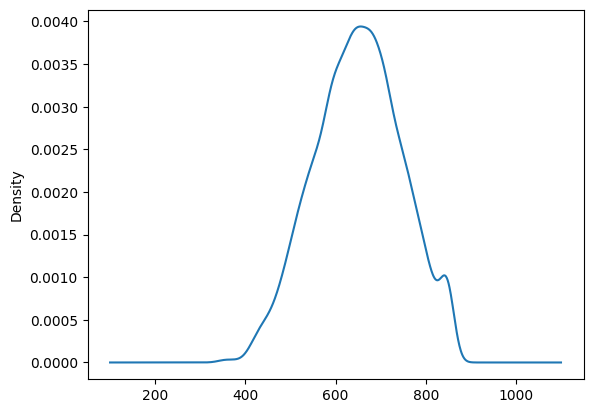

In [15]:
df["CreditScore"].plot(kind="kde")

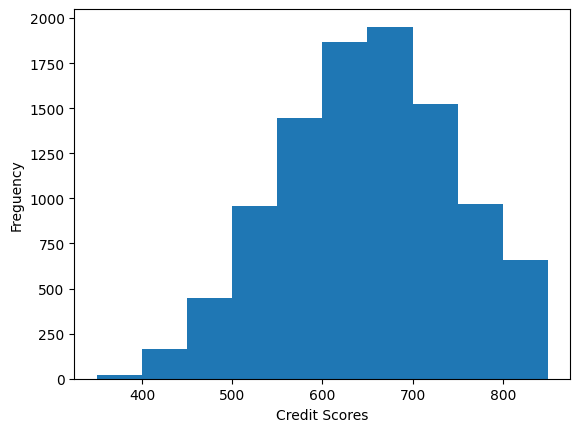

In [16]:
plt.hist(df["CreditScore"])
plt.xlabel("Credit Scores")
plt.ylabel("Freguency")
plt.show()

- How is the customer base distributed across different Geographic locations?

In [17]:
df["Geography"] = df["Geography"].replace(["F","G","Germeny","Spin"],["France","Germany","Germany","Spain"])

In [18]:
df.groupby(by="Geography")["CustomerId"].count()

Geography
France     5014
Germany    2509
Spain      2477
Name: CustomerId, dtype: int64

In [19]:
# df.groupby(by=["Geography","Churned/Retained"])["CustomerId"].count()
pd.crosstab(df.Geography, df["Churned/Retained"], normalize="index")*100

Churned/Retained,Churned,Retained
Geography,,
France,16.154767,83.845233
Germany,32.443204,67.556796
Spain,16.673395,83.326605


- What is the average account balance, and how does its distribution look?

76478.54


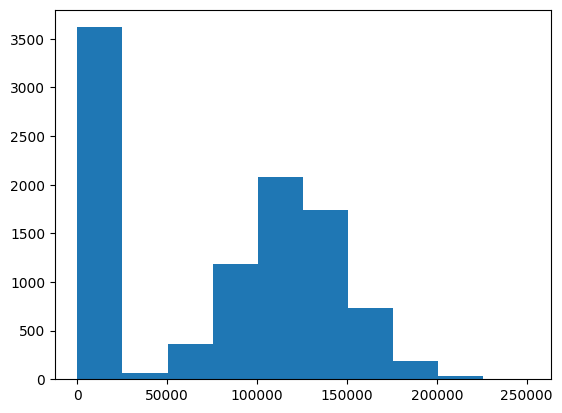

In [20]:
Avg_Account_Balance = round(df["Balance"].mean(),2)
print(Avg_Account_Balance)

plt.hist(df["Balance"])
plt.show()


- Is there a significant difference in churn rates between Genders?

In [21]:
df["Gender"] = df["Gender"].replace(["F","M"],["Female","Male"])
df.groupby(by="Gender")["Churned/Retained"].value_counts()

Gender  Churned/Retained
Female  Retained            3404
        Churned             1139
Male    Retained            4559
        Churned              898
Name: count, dtype: int64

<Axes: xlabel='Gender'>

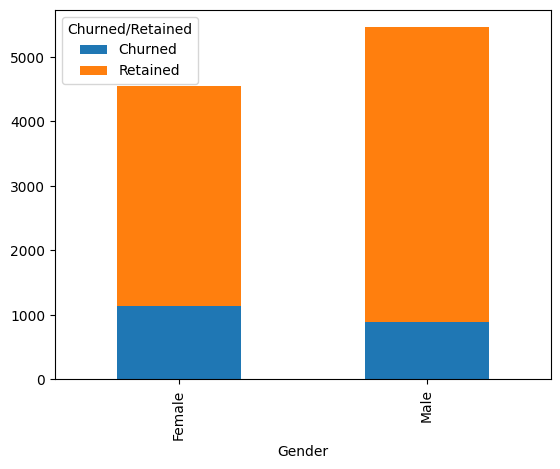

In [22]:
x = pd.crosstab(df["Gender"], df["Churned/Retained"])
x.plot(kind="bar",stacked=True)

- Does the number of products a customer uses (NumOfProducts) influence their likelihood to churn?

In [23]:
# This gives the percentage of Churned vs Retained for each product count
pd.crosstab(df['NumOfProducts'], df['Churned/Retained'], normalize='index') *100

Churned/Retained,Churned,Retained
NumOfProducts,,
1.0,27.701104,72.298896
2.0,7.647187,92.352813
3.0,83.018868,16.981132
4.0,100.000000,0.000000


In [24]:
bins = [0, 30, 45, 60, 100]
labels = ['Young', 'Adult', 'Mid-Age', 'Senior']

df["Agegroup"] = pd.cut(df["Age"],bins=bins, labels=labels)


<Axes: xlabel='Agegroup'>

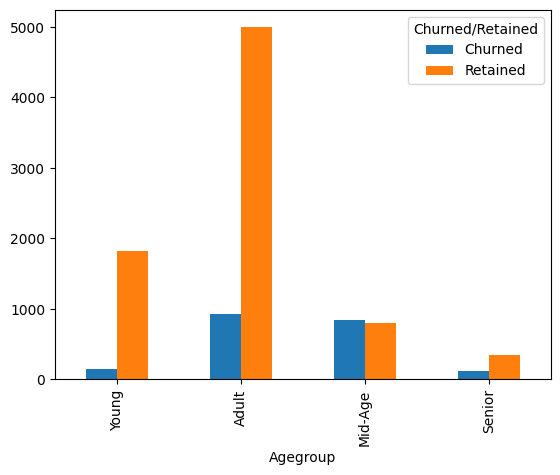

In [25]:
x = pd.crosstab(df["Agegroup"],df["Churned/Retained"]).plot(kind="bar")
x

- Do customers with higher estimated salaries tend to have higher balances, or is there no correlation?

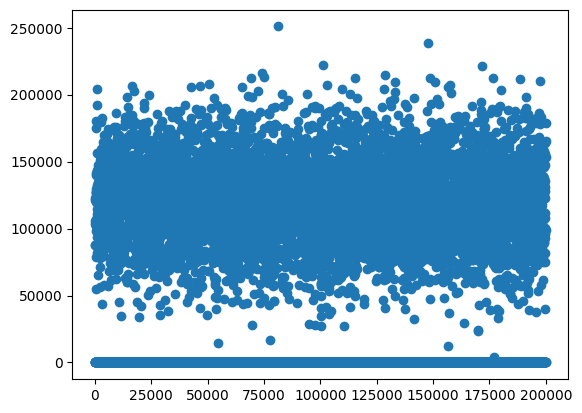

In [26]:
plt.scatter(data=df, y="Balance", x="EstimatedSalary")

In [27]:
df.corr(numeric_only=True)

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary
CustomerId,1.000000,0.005516,0.009117,-0.014486,-0.012690,0.016734,0.001689,0.016066
CreditScore,0.005516,1.000000,-0.004584,0.000767,0.005916,0.012686,0.025292,-0.000922
Age,0.009117,-0.004584,1.000000,-0.010220,0.028860,-0.030914,0.084726,-0.006236
Tenure,-0.014486,0.000767,-0.010220,1.000000,-0.011826,0.013643,-0.028860,0.007636
Balance,-0.012690,0.005916,0.028860,-0.011826,1.000000,-0.304161,-0.010369,0.012382
NumOfProducts,0.016734,0.012686,-0.030914,0.013643,-0.304161,1.000000,0.008677,0.014276
IsActiveMember,0.001689,0.025292,0.084726,-0.028860,-0.010369,0.008677,1.000000,-0.011211
EstimatedSalary,0.016066,-0.000922,-0.006236,0.007636,0.012382,0.014276,-0.011211,1.000000


In [28]:
df["HasCrCard"] = df["HasCrCard"].replace("No",0)
df["HasCrCard"] = df["HasCrCard"].astype("int64")

<Axes: xlabel='HasCrCard,IsActiveMember'>

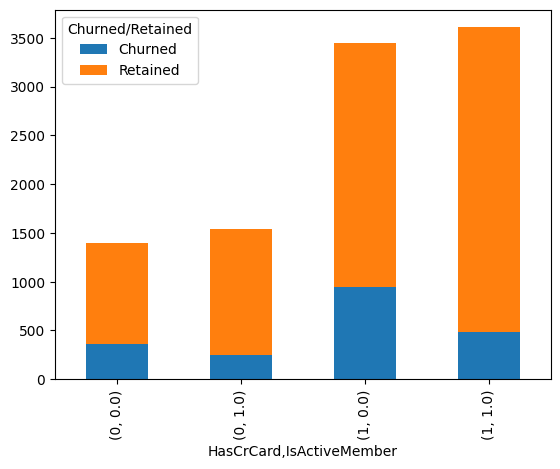

In [29]:
df.groupby(by=["HasCrCard","IsActiveMember"])["Churned/Retained"].value_counts().unstack().plot(kind="bar", stacked=True)

In [30]:
pd.pivot_table(data=df, index="HasCrCard",columns="Churned/Retained",values="IsActiveMember", aggfunc="count")

Churned/Retained,Churned,Retained
HasCrCard,,
0,611,2330
1,1426,5633


- What is the profile of a "High-Value Churner"?

In [31]:
HighValue = df[(df["CreditScore"] > 700) & (df["Balance"] > 100000)]

In [32]:
Churn_Rate_HVC = ((HighValue["Churned/Retained"].value_counts())/HighValue.shape[0] * 100)

In [33]:
Original = ((df["Churned/Retained"].value_counts())/df.shape[0] * 100)

In [34]:
Churn_Rate_HVC.compare(Original)

,self,other
Churned/Retained,,
Retained,75.033378,79.63
Churned,24.966622,20.37


- Can we identify the "Retention sweet spot" for tenure?

<Axes: xlabel='Tenure'>

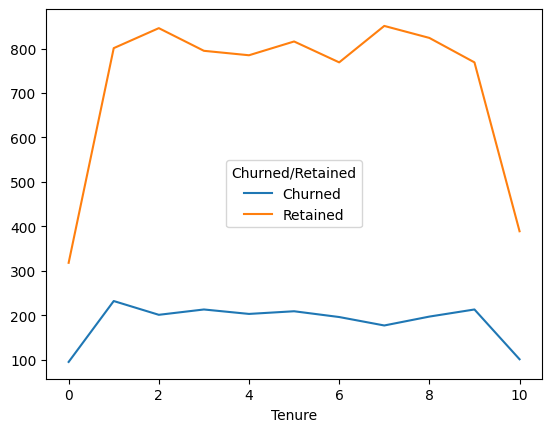

In [35]:
df.groupby(by=["Tenure","Churned/Retained"])["Tenure"].value_counts().sort_values(ascending=False).unstack().plot(kind="line")

In [36]:
df.drop(columns="Agegroup",inplace=True)

In [37]:
df

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churned/Retained
0,15634602,619,France,Female,42.0,2.0,0.00,1.0,1,1.0,101348.88,Churned
1,15647311,608,Spain,Female,41.0,1.0,83807.86,1.0,0,1.0,112542.58,Retained
2,15619304,502,France,Female,42.0,8.0,159660.80,3.0,1,0.0,113931.57,Churned
3,15701354,699,France,Female,39.0,1.0,0.00,2.0,0,0.0,93826.63,Retained
4,15737888,850,Spain,Female,43.0,2.0,125510.82,1.0,1,1.0,79084.10,Retained
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39.0,5.0,0.00,2.0,1,0.0,96270.64,Retained
9996,15569892,516,France,Male,35.0,10.0,57369.61,1.0,1,1.0,101699.77,Retained
9997,15584532,709,France,Female,36.0,7.0,0.00,1.0,0,1.0,42085.58,Churned
9998,15599131,650,Germany,Male,26.0,4.0,214346.96,2.0,1,0.0,128815.33,Retained


In [38]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["CustomerId", "Churned/Retained"])
y = df["Churned/Retained"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= 0.75, random_state=42) 


In [39]:
X_train.head(2)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
4901,673,France,Male,59.0,0.0,178058.06,2.0,0,1.0,21063.71
4375,792,Germany,Male,36.0,5.0,115725.24,2.0,0,0.0,1871.25


In [40]:
y_train[:2]

4901     Churned
4375    Retained
Name: Churned/Retained, dtype: object

In [41]:

nums = X.select_dtypes(exclude="object").columns
nums

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

trans2 =ColumnTransformer(transformers=[
    ("T2",StandardScaler(),nums),
    ("T3",OneHotEncoder(sparse_output=False, drop="first"),["Geography","Gender"])
], remainder="passthrough")
trans2

ColumnTransformer(remainder='passthrough',
                  transformers=[('T2', StandardScaler(),
                                 Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')),
                                ('T3',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['Geography', 'Gender'])])

In [43]:
label = LabelEncoder()
y_train_label = label.fit_transform(y_train)
y_test_label = label.fit_transform(y_test)

In [44]:
# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import LogisticRegression

# pipe = Pipeline(steps=[
#     ("preprocessor", trans2),
#     ("model",LogisticRegression(class_weight="balanced"))
# ])
# pipe

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline(steps=[
    ("preprocessor", trans2),
    ("model",RandomForestClassifier(n_estimators=100, random_state=42))
])
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('T2', StandardScaler(),
                                                  Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')),
                                                 ('T3',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Geography', 'Gender'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [46]:
pipe.fit(X_train, y_train_label)

y_pred = pipe.predict(X_test)
y_pred[:5]

array([1, 1, 1, 1, 1])

In [47]:
X_test[:5]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
6252,664,Germany,Female,49.0,5.0,127421.78,2.0,1,0.0,108876.75
4684,623,France,Male,43.0,1.0,0.00,2.0,1,1.0,146379.30
1731,601,Spain,Female,44.0,4.0,0.00,2.0,1,0.0,58561.31
4742,724,Germany,Male,34.0,6.0,118235.70,2.0,0,0.0,157137.23
4521,560,Spain,Female,27.0,7.0,124995.98,1.0,1,1.0,114669.79


In [48]:
y_test[:5]

6252     Churned
4684    Retained
1731    Retained
4742    Retained
4521    Retained
Name: Churned/Retained, dtype: object

In [49]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test_label,y_pred)

0.8696

In [50]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test_label,y_pred))

[[ 227  251]
 [  75 1947]]


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test_label,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.47      0.58       478
           1       0.89      0.96      0.92      2022

    accuracy                           0.87      2500
   macro avg       0.82      0.72      0.75      2500
weighted avg       0.86      0.87      0.86      2500



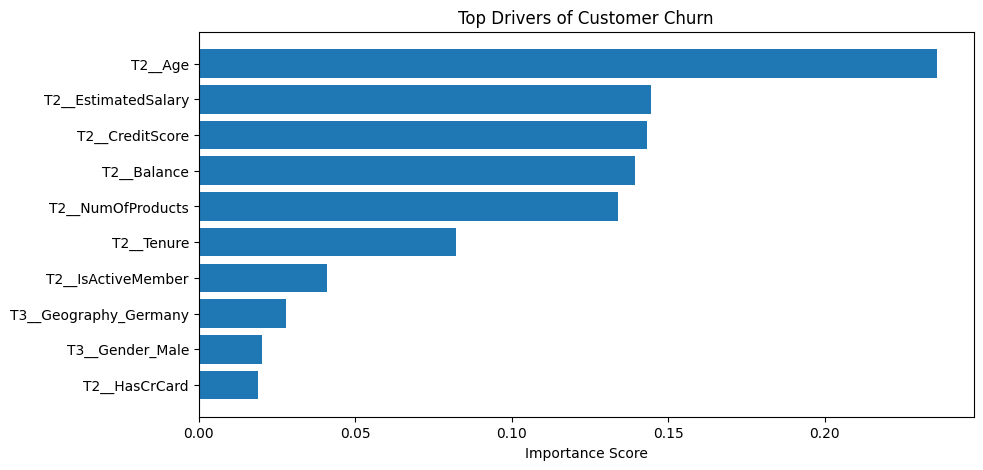

Top 3 Drivers:
               Feature  Importance
1              T2__Age    0.235765
7  T2__EstimatedSalary    0.144367
0      T2__CreditScore    0.143181


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get the feature names from the preprocessor
# This handles the names after One-Hot Encoding and Scaling
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the importance scores from the RandomForest model
importances = pipe.named_steps['model'].feature_importances_

# 3. Create a DataFrame for easy sorting and plotting
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Plot the results
plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis() # Highest importance at the top
plt.title("Top Drivers of Customer Churn")
plt.xlabel("Importance Score")
plt.show()

# Print the top 3
print("Top 3 Drivers:")
print(feature_importance_df.iloc[:3])

In [53]:
feature_importance_df

,Feature,Importance
1,T2__Age,0.235765
7,T2__EstimatedSalary,0.144367
0,T2__CreditScore,0.143181
3,T2__Balance,0.139311
4,T2__NumOfProducts,0.133854
2,T2__Tenure,0.082156
6,T2__IsActiveMember,0.040828
8,T3__Geography_Germany,0.027868
10,T3__Gender_Male,0.020173
5,T2__HasCrCard,0.018948


In [54]:
df.columns

Index(['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Churned/Retained'],
      dtype='object')

In [55]:
df = pd.DataFrame({
    'CreditScore': [600],
    'Geography': ['France'],
    'Gender': ['Male'],
    'Age': [50],
    'Tenure': [3],
    'Balance': [60000],
    'NumOfProducts': [2],
    'HasCrCard': [1],
    'IsActiveMember': [0],
    'EstimatedSalary': [50000]
})

df


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,600,France,Male,50,3,60000,2,1,0,50000


In [56]:
prediction = pipe.predict(df)
if prediction == 1:
    print("Retained")
else:
    print("Churn")

Retained


In [57]:
df2 = X_test

In [58]:
df2["Churned/Retained"] = y_test.values

In [59]:
onlychurned = df2[df2["Churned/Retained"]=="Churned"]
Total_Value_at_Risk = onlychurned["Balance"].sum()
Total_Value_at_Risk

np.float64(42721202.31999999)

In [60]:
report = classification_report(y_test_label,y_pred, output_dict=True)
report

{'0': {'precision': 0.7516556291390728,
  'recall': 0.47489539748953974,
  'f1-score': 0.5820512820512821,
  'support': 478.0},
 '1': {'precision': 0.8858052775250227,
  'recall': 0.9629080118694362,
  'f1-score': 0.9227488151658768,
  'support': 2022.0},
 'accuracy': 0.8696,
 'macro avg': {'precision': 0.8187304533320477,
  'recall': 0.718901704679488,
  'f1-score': 0.7524000486085795,
  'support': 2500.0},
 'weighted avg': {'precision': 0.860155864753629,
  'recall': 0.8696,
  'f1-score': 0.8576074468343664,
  'support': 2500.0}}

In [61]:
Recall_Churn = report['0']['recall']
Recall_Churn

0.47489539748953974

In [62]:
Model_Captured_Value = Total_Value_at_Risk * Recall_Churn

In [63]:
# Assume a 20% Retention Success Rate (a common industry benchmark for win-back campaigns)
Potential_Revenue_Saved = Model_Captured_Value * 0.20
Potential_Revenue_Saved

np.float64(4057620.471397489)

In [65]:
pip install "numpy<=2.1.0"

Note: you may need to restart the kernel to use updated packages.


In [66]:
pip install --upgrade numba shap

Note: you may need to restart the kernel to use updated packages.


In [70]:
import joblib

# This saves your trained pipeline so the web app can use it later
joblib.dump(pipe, 'churn_model.pkl')

['churn_model.pkl']